In [1]:
# import pandas --- spreadsheet library
import pandas as pd
import numpy as np
import os

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, make_yield_plot, compare, smoothen
from myio import read_in_weather_data

In [2]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

In [3]:
%matplotlib inline

In [4]:
def read_in_observed_yield(party, fn):
    """ Read in a csv of observed yields and return the df. """
    
    fdir = '../../Data/Calibration Data/{:}/Clean data'.format(party)

    ydir = 'Yield'

    fp = os.path.join(fdir,ydir,fn)

    # observed yield
    dfo = pd.read_csv(fp)
    dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
    dfo = dfo.dropna(how='all')
    dfo['Y (kg/ha/yr)'] = 1000*dfo['Y (t/ha/mo)']*(365/dfo.index.days_in_month)
    
    return dfo

# a small test to check the function
assert read_in_observed_yield('Sinarmas', 'Hnae-1986.csv') is not None

In [5]:
def fetch_dfs(fdirs, fname):
    """ Read in spreadsheets. """
    
    dfs = {} 

    which = 'observed'
    fpath = os.path.join(fdirs[which], fname)
    dfs[which] = pd.read_csv(fpath, index_col = 'Month')
        
    which = 'potential'
    fpath = os.path.join(fdirs[which], fname)
    dfs[which] = pd.read_csv(fpath, index_col = 'date')
    
    which = 'water-limited'
    fpath = os.path.join(fdirs[which], fname)
    dfs[which] = pd.read_csv(fpath, index_col = 'date')

    for key, df in dfs.items():
        
        df.index = pd.to_datetime(df.index)
        dfs[key] = df
    
    return dfs

In [6]:
fdirs = ['observed', 'potential', 'water-limited']

fdirs = {k:os.path.join("results", k) for k in fdirs}

In [7]:
fdirs

{'observed': 'results\\observed',
 'potential': 'results\\potential',
 'water-limited': 'results\\water-limited'}

In [8]:
fnames = os.listdir(fdirs['observed'])

fname = fnames[0]

	Saving at: plots\incl_yield_factors\HNAE-total.png
	Saving at: plots\yield_only\HNAE-total.png


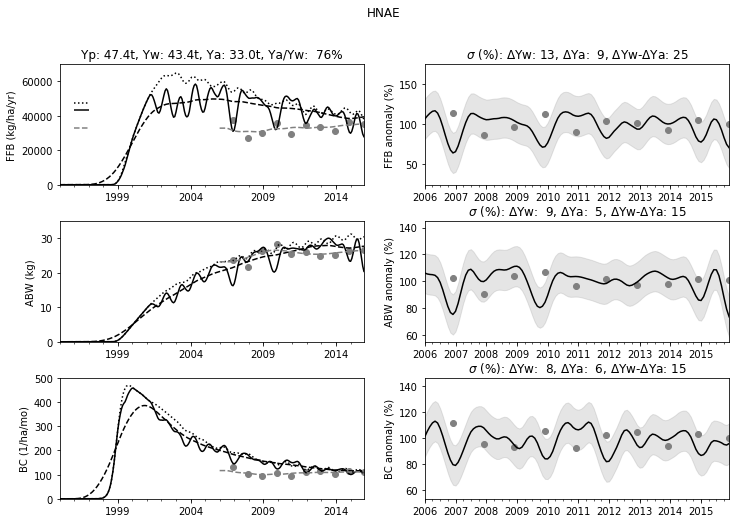

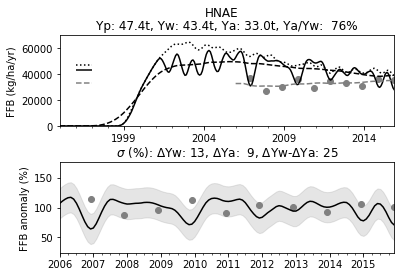

In [9]:
for fname in fnames:

    dfs = fetch_dfs(fdirs, fname)

    overview = pd.read_excel('summary_table.xls')

    row = overview['Filename_clean'] == fname

    info = {k:v for k,v in zip(list(overview), overview.loc[row].values[0])}

    title = info['Filename_weatherdata_clean'].split('.')[0]

    filepath = os.path.join("plots","incl_yield_factors","{:}.png".format(title))

    make_overview(dfs['water-limited'],
                  dfs['potential'],
                  dfs['observed'],
                  filepath, window=12, title=title)
    
    filepath = os.path.join("plots","yield_only","{:}.png".format(title))
    
    make_yield_plot(dfs['water-limited'],
                  dfs['potential'],
                  dfs['observed'],
                  filepath, window=12, title=title)    
    
    
    break;